# VAE Latent Manifold Lab — Training Notebook

Run all cells top-to-bottom on a T4 GPU runtime (~30 min total).
After Cell 12 finishes, download the zip files and JSON files into your project folder.

In [1]:
# Cell 1 — Install
!pip install tensorflowjs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.


In [2]:
# Cell 2 — Imports
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflowjs as tfjs
import json
print('TF version:', tf.__version__)

TF version: 2.19.0


In [3]:
# Cell 3 — Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train, -1).astype('float32') / 255.0
x_test  = np.expand_dims(x_test,  -1).astype('float32') / 255.0
print('Train:', x_train.shape, '  Test:', x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28, 1)   Test: (10000, 28, 28, 1)


In [4]:
# Cell 4 — Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [5]:
# Cell 5 — Build Encoder
def build_encoder():
    inputs    = keras.Input(shape=(28, 28, 1))
    x         = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inputs)
    x         = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x         = layers.Flatten()(x)
    x         = layers.Dense(16, activation='relu')(x)
    z_mean    = layers.Dense(2, name='z_mean')(x)
    z_log_var = layers.Dense(2, name='z_log_var')(x)
    z         = Sampling()([z_mean, z_log_var])
    return keras.Model(inputs, [z_mean, z_log_var, z], name='encoder')

build_encoder().summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Cell 6 — Build Decoder
def build_decoder():
    inputs  = keras.Input(shape=(2,))
    x       = layers.Dense(7 * 7 * 64, activation='relu')(inputs)
    x       = layers.Reshape((7, 7, 64))(x)
    x       = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x       = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    outputs = layers.Conv2DTranspose(1,  3, activation='sigmoid', padding='same')(x)
    return keras.Model(inputs, outputs, name='decoder')

build_decoder().summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Cell 7 — VAE Class with beta
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(
                keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
            ))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

In [8]:
# Cell 8 — Train VAE (beta=1)
encoder_vae = build_encoder()
decoder_vae = build_decoder()
vae = VAE(encoder_vae, decoder_vae, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(x_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - kl_loss: 2.9022 - loss: 212.3594 - recon_loss: 209.4573
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.1987 - loss: 179.1416 - recon_loss: 173.9431
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.5572 - loss: 167.8151 - recon_loss: 162.2581
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.8809 - loss: 162.7285 - recon_loss: 156.8475
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 6.1407 - loss: 159.7462 - recon_loss: 153.6054
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 6.2466 - loss: 158.0383 - recon_loss: 151.7918
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 6.2930 - loss: 156.7939 - recon_loss: 150.5009
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 6.3429 - loss: 155.9038 - recon_loss: 149.5608
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 6.4033 - loss: 155.2139 - recon_loss: 148.8106
Epoch 10

In [9]:
# Cell 9 — Train Autoencoder (beta=0)
encoder_ae = build_encoder()
decoder_ae = build_decoder()
ae = VAE(encoder_ae, decoder_ae, beta=0.0)
ae.compile(optimizer=keras.optimizers.Adam())
ae.fit(x_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 59.1320 - loss: 213.2273 - recon_loss: 213.2273
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 94.6421 - loss: 179.1597 - recon_loss: 179.1597 
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 84.2243 - loss: 163.0479 - recon_loss: 163.0479
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 77.2322 - loss: 157.8020 - recon_loss: 157.8020
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 62.1726 - loss: 154.4348 - recon_loss: 154.4348
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 51.7463 - loss: 152.2493 - recon_loss: 152.2493
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 47.6961 - loss: 150.6144 - recon_loss: 150.6144
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 45.4161 - loss: 149.3451 - recon_loss: 149.3451
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 44.0577 - loss: 148.4170 - recon_loss: 148.417

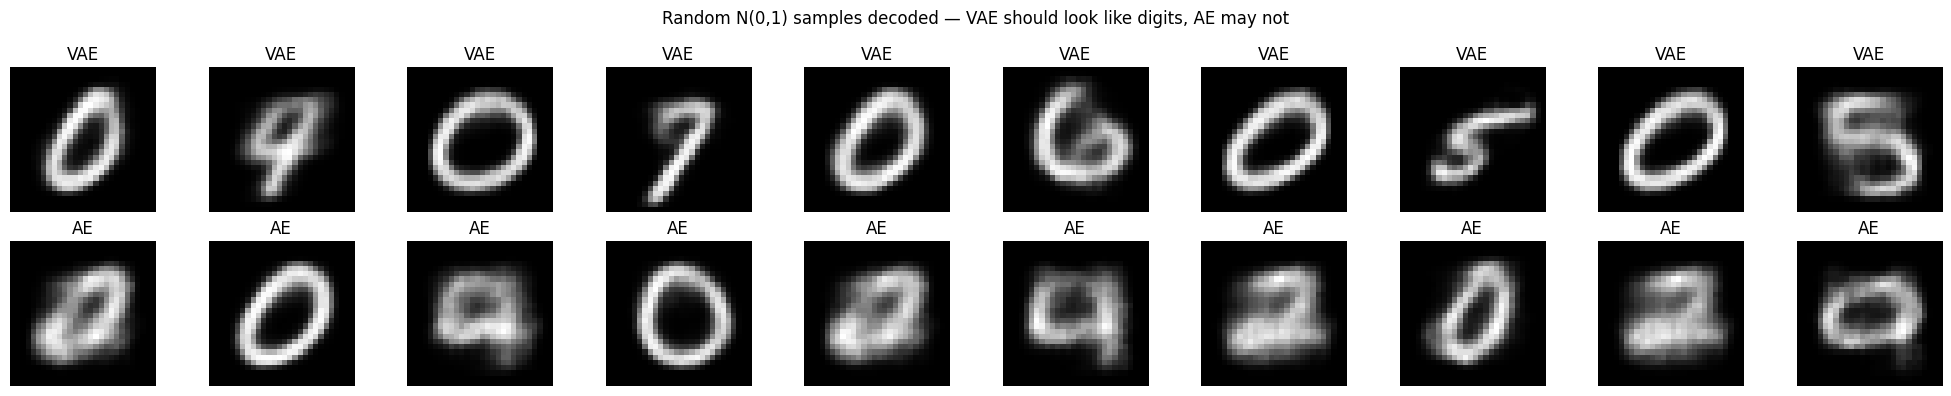

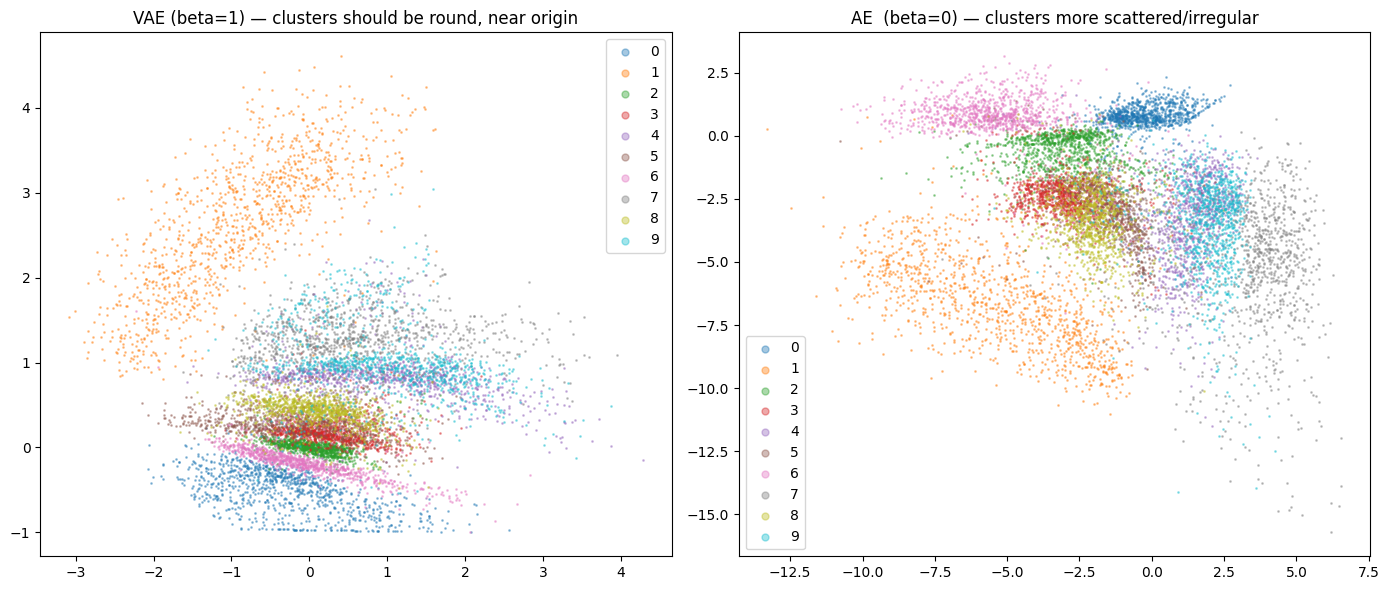

In [10]:
# Cell 10 — Sanity checks (run before exporting)
import matplotlib.pyplot as plt

# Visual decode check
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    z_sample = np.random.normal(size=(1, 2)).astype('float32')
    decoded_vae = decoder_vae.predict(z_sample, verbose=0).squeeze()
    decoded_ae  = decoder_ae.predict(z_sample, verbose=0).squeeze()
    axes[0, i].imshow(decoded_vae, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('VAE')
    axes[1, i].imshow(decoded_ae, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('AE')
plt.suptitle('Random N(0,1) samples decoded — VAE should look like digits, AE may not')
plt.tight_layout()
plt.show()

# Scatter check
z_mean_vae, _, _ = encoder_vae.predict(x_test, verbose=0)
z_mean_ae,  _, _ = encoder_ae.predict(x_test,  verbose=0)

colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for digit in range(10):
    mask = y_test == digit
    axes[0].scatter(z_mean_vae[mask, 0], z_mean_vae[mask, 1], s=1, alpha=0.4, color=colors[digit], label=str(digit))
    axes[1].scatter(z_mean_ae[mask,  0], z_mean_ae[mask,  1], s=1, alpha=0.4, color=colors[digit], label=str(digit))
axes[0].set_title('VAE (beta=1) — clusters should be round, near origin')
axes[1].set_title('AE  (beta=0) — clusters more scattered/irregular')
for ax in axes:
    ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

In [11]:
# Cell 11 — Export to TensorFlow.js
tfjs.converters.save_keras_model(decoder_vae, 'tfjs_decoder_vae')
tfjs.converters.save_keras_model(decoder_ae,  'tfjs_decoder_ae')
tfjs.converters.save_keras_model(encoder_vae, 'tfjs_encoder_vae')
print('Exported decoder_vae, decoder_ae, encoder_vae')

failed to lookup keras version from the file,
    this is likely a weight only file
failed to lookup keras version from the file,
    this is likely a weight only file
failed to lookup keras version from the file,
    this is likely a weight only file
Exported decoder_vae, decoder_ae, encoder_vae


In [12]:
# Cell 12 — Pre-compute Scatter Coordinates
z_mean_vae, _, _ = encoder_vae.predict(x_test, verbose=0)
z_mean_ae,  _, _ = encoder_ae.predict(x_test,  verbose=0)

scatter_vae = [{"x": float(z[0]), "y": float(z[1]), "label": int(y_test[i])}
               for i, z in enumerate(z_mean_vae)]
scatter_ae  = [{"x": float(z[0]), "y": float(z[1]), "label": int(y_test[i])}
               for i, z in enumerate(z_mean_ae)]

with open('scatter_vae.json', 'w') as f: json.dump(scatter_vae, f)
with open('scatter_ae.json',  'w') as f: json.dump(scatter_ae,  f)
print(f'Wrote {len(scatter_vae)} VAE points and {len(scatter_ae)} AE points')

Wrote 10000 VAE points and 10000 AE points


In [13]:
# Cell 13 — Download Everything
from google.colab import files
import shutil

shutil.make_archive('vae_weights', 'zip', '.', 'tfjs_decoder_vae')
shutil.make_archive('ae_weights',  'zip', '.', 'tfjs_decoder_ae')
shutil.make_archive('enc_weights', 'zip', '.', 'tfjs_encoder_vae')

files.download('vae_weights.zip')
files.download('ae_weights.zip')
files.download('enc_weights.zip')
files.download('scatter_vae.json')
files.download('scatter_ae.json')
print('Downloads triggered. Unzip each archive into your project folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered. Unzip each archive into your project folder.
